In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_score, recall_score, f1_score)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("C:/Users/User/Desktop/ML 2/ML-assignment/data/kidney_disease.csv")

print("Shape:", df.shape)
print("\nColumn names:", list(df.columns))
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['classification'].value_counts())
df.head()

Shape: (400, 26)

Column names: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Missing values:
 id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

Target distribution:
 classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
data = df.copy()

# Strip whitespace from column names
data.columns = data.columns.str.strip()

# Replace tab/question mark artifacts with NaN
data = data.replace({'\t?': np.nan, '?': np.nan}, regex=False)
data = data.replace(r'^\s*$', np.nan, regex=True)

# Force numeric columns to numeric dtype
numeric_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu',
                'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Clean and encode target column
data['classification'] = data['classification'].astype(str).str.strip()
data['classification'] = data['classification'].replace({'ckd\t': 'ckd', 'notckd': 'notckd'})
data['classification'] = data['classification'].map({'ckd': 1, 'notckd': 0})

# Drop rows where target is still NaN
data = data.dropna(subset=['classification'])
y = data['classification'].astype(int)

# Encode categorical features
cat_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
for col in cat_cols:
    data[col] = data[col].astype(str).str.strip().str.lower()
    data[col] = data[col].replace({'nan': np.nan, 'none': np.nan, '': np.nan})

le = LabelEncoder()
for col in cat_cols:
    non_null = data[col].dropna()
    le.fit(non_null)
    data[col] = data[col].map(lambda x: le.transform([x])[0]
                               if pd.notna(x) and x in le.classes_
                               else np.nan)

# Drop id and target from features
X = data.drop(columns=['id', 'classification'], errors='ignore')

# Impute all remaining NaN with column mean
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Preprocessing complete!")
print("X shape:", X_imputed.shape)
print("y shape:", y.shape)
print("Class counts:\n", y.value_counts())

Preprocessing complete!
X shape: (400, 24)
y shape: (400,)
Class counts:
 classification
1    250
0    150
Name: count, dtype: int64


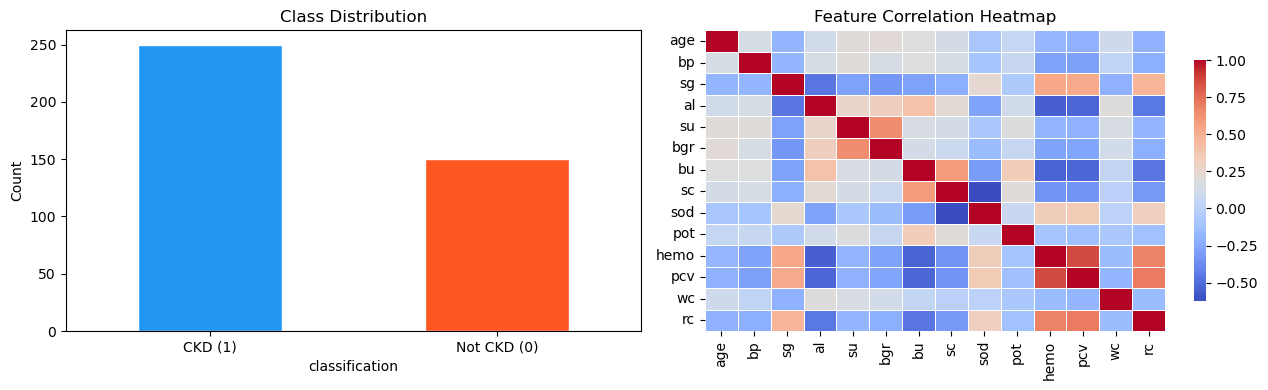

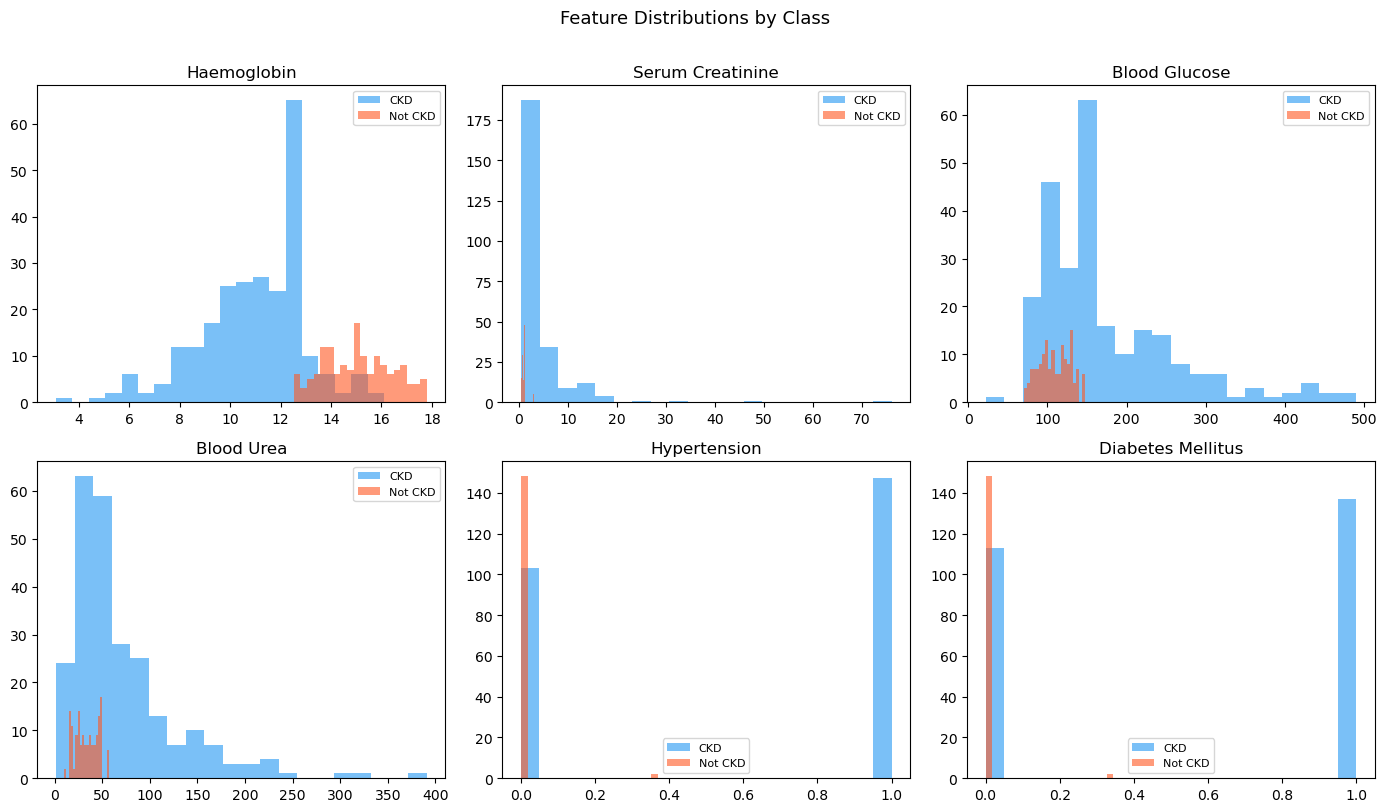

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
y.value_counts().plot(kind='bar', ax=axes[0],
                      color=['#2196F3', '#FF5722'], edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['CKD (1)', 'Not CKD (0)'], rotation=0)
axes[0].set_ylabel('Count')

# Correlation heatmap
corr = X_imputed[numeric_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', annot=False,
            linewidths=0.4, cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

# Feature distributions by class
key_features = ['hemo', 'sc', 'bgr', 'bu', 'htn', 'dm']
feature_labels = ['Haemoglobin', 'Serum Creatinine', 'Blood Glucose',
                  'Blood Urea', 'Hypertension', 'Diabetes Mellitus']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, (feat, label) in enumerate(zip(key_features, feature_labels)):
    ax = axes[i // 3][i % 3]
    ax.hist(X_imputed[feat][y == 1], bins=20, alpha=0.6,
            color='#2196F3', label='CKD')
    ax.hist(X_imputed[feat][y == 0], bins=20, alpha=0.6,
            color='#FF5722', label='Not CKD')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 320
Test samples     : 80
Features         : 24
